# Cephalopod Behavioral Sentiment Analysis
### GSoC 2026 Entry Task

Extracts two behavioral features from a cephalopod video clip and visualises activity over time.

- **Motion magnitude** — frame differencing to capture locomotor activity
- **Histogram change** — inter-frame colour variation as a proxy for chromatophore activity

Features are loaded from a pre-computed `.npz` file (run `analyze.py` first). For the written analysis and results discussion, see `report.tex`.

## Setup

In [1]:
import cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import uniform_filter1d
from IPython.display import Image, display
import os

FEATURES_PATH = 'data/data_octopus_features.npz'
VIDEO_PATH    = 'data/data_octopus.mp4'
PLOT_DIR      = 'plots/data_octopus'
os.makedirs(PLOT_DIR, exist_ok=True)

data = np.load(FEATURES_PATH)
motion   = data['motion']
hist_ch  = data['hist_ch']
fps      = float(data['fps'])
n_frames = int(data['n_frames'])
duration = float(data['duration'])
times    = np.arange(len(motion)) / fps

print(f'{n_frames} frames  |  {duration:.1f}s  |  {fps:.2f} fps')

1415 frames  |  59.0s  |  23.98 fps


## Video Preview

## Frame Preview

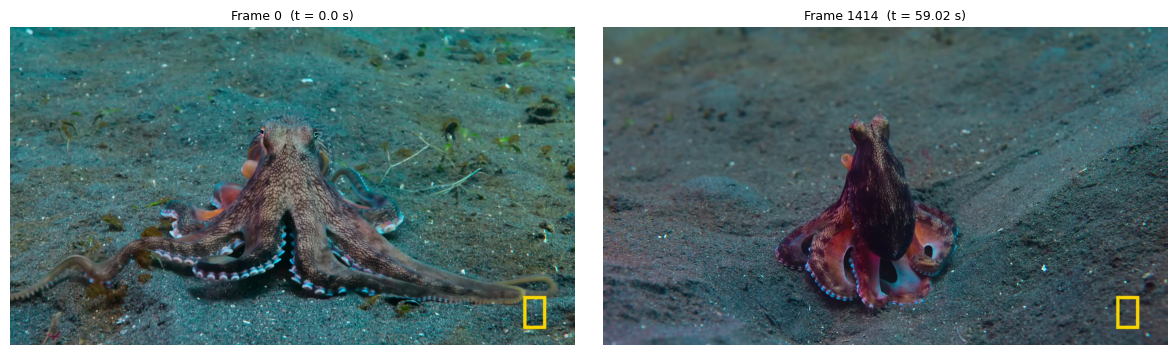

In [2]:
cap = cv2.VideoCapture(VIDEO_PATH)
frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frames.append(frame)
cap.release()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, idx, label in zip(axes, [0, -1], [f'Frame 0  (t = 0.0 s)', f'Frame {len(frames)-1}  (t = {duration:.2f} s)']):
    ax.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.tight_layout()
out = f'{PLOT_DIR}/frame_preview.png'
plt.savefig(out, bbox_inches='tight')
plt.close()
display(Image(out))

## Feature Extraction

### Motion Magnitude

Mean absolute pixel difference between consecutive grayscale frames. Higher values indicate more physical movement in the scene.

### Histogram Change

Cephalopods control chromatophores to rapidly shift skin colour and pattern. We measure this as `1 - correlation` between consecutive BGR histograms — 0 means no change, 1 means maximal change.

In [3]:
def compute_motion_magnitude(frames):
    magnitudes = np.empty(len(frames) - 1)
    prev = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY).astype(np.float32)
    for i, frame in enumerate(frames[1:]):
        curr = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)
        magnitudes[i] = np.mean(np.abs(curr - prev))
        prev = curr
    return magnitudes

motion = compute_motion_magnitude(frames)
print(f'Motion   — mean: {motion.mean():.3f}  max: {motion.max():.3f}')

Motion   — mean: 7.072  max: 61.319


In [4]:
def compute_histogram_changes(frames):
    def frame_hist(f):
        hist = np.zeros(256 * 3, dtype=np.float32)
        for c in range(3):
            h = cv2.calcHist([f], [c], None, [256], [0, 256]).flatten()
            hist[c*256:(c+1)*256] = h
        cv2.normalize(hist, hist)
        return hist

    changes = np.empty(len(frames) - 1)
    prev_h = frame_hist(frames[0])
    for i, frame in enumerate(frames[1:]):
        curr_h = frame_hist(frame)
        corr = cv2.compareHist(prev_h, curr_h, cv2.HISTCMP_CORREL)
        changes[i] = 1.0 - float(np.clip(corr, -1.0, 1.0))
        prev_h = curr_h
    return changes

hist_ch = compute_histogram_changes(frames)
print(f'Hist-chg — mean: {hist_ch.mean():.4f}  max: {hist_ch.max():.4f}')

Hist-chg — mean: 0.0043  max: 0.6853


## Visualisation

Both signals are smoothed with a ~0.4s uniform window and combined into a normalised activity score. Shaded spans mark periods exceeding `mean + threshold × std`.

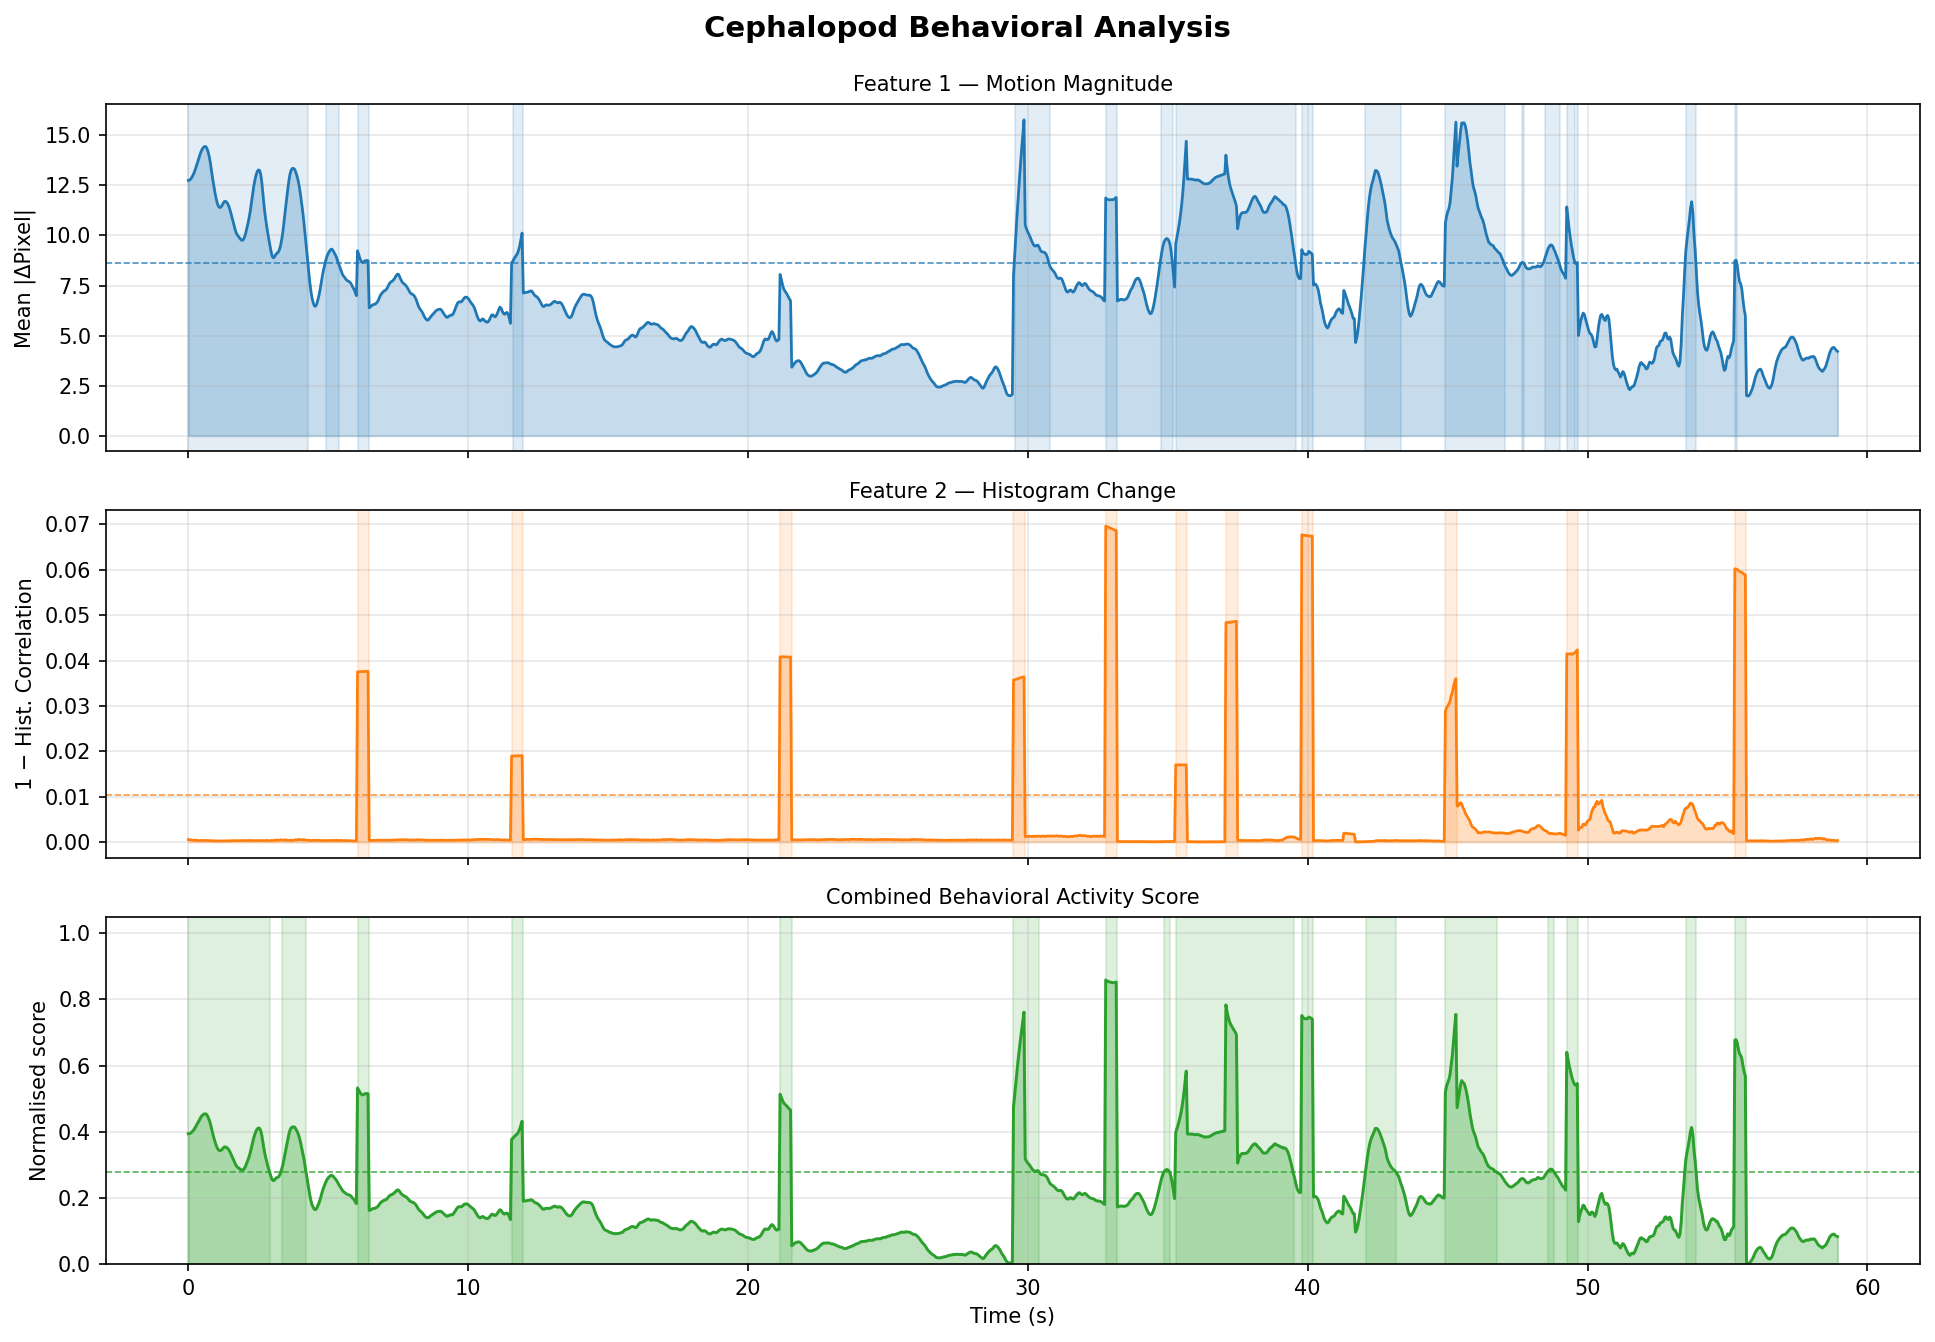

In [5]:
def smooth(signal, fps, window_sec=0.4):
    w = max(1, int(round(fps * window_sec)))
    return uniform_filter1d(signal, size=w)

def norm01(x):
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 0 else np.zeros_like(x)

def activity_spans(signal, times, threshold):
    spans, in_span, t0 = [], False, 0.0
    for i, v in enumerate(signal > threshold):
        if v and not in_span:    in_span, t0 = True, times[i]
        elif not v and in_span:  spans.append((t0, times[i])); in_span = False
    if in_span: spans.append((t0, times[-1]))
    return spans

sm_motion = smooth(motion, fps)
sm_hist   = smooth(hist_ch, fps)
score     = 0.5 * norm01(sm_motion) + 0.5 * norm01(sm_hist)

thr_m = sm_motion.mean() + 0.5 * sm_motion.std()
thr_h = sm_hist.mean()   + 0.5 * sm_hist.std()
thr_s = score.mean()     + 0.4 * score.std()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Cephalopod Behavioral Analysis', fontsize=14, fontweight='bold', y=0.99)

for ax, sig, thr, color, title, ylabel in [
    (axes[0], sm_motion, thr_m, '#1f77b4', 'Feature 1 — Motion Magnitude', 'Mean |ΔPixel|'),
    (axes[1], sm_hist,   thr_h, '#ff7f0e', 'Feature 2 — Histogram Change', '1 − Hist. Correlation'),
]:
    ax.fill_between(times, sig, alpha=0.25, color=color)
    ax.plot(times, sig, color=color, lw=1.3)
    ax.axhline(thr, color=color, ls='--', lw=0.8, alpha=0.8)
    for t0, t1 in activity_spans(sig, times, thr):
        ax.axvspan(t0, t1, color=color, alpha=0.13)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)

ax = axes[2]
ax.fill_between(times, score, alpha=0.3, color='#2ca02c')
ax.plot(times, score, color='#2ca02c', lw=1.4)
ax.axhline(thr_s, color='#2ca02c', ls='--', lw=0.8, alpha=0.8)
for t0, t1 in activity_spans(score, times, thr_s):
    ax.axvspan(t0, t1, color='#2ca02c', alpha=0.15)
ax.set_ylabel('Normalised score', fontsize=10)
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_title('Combined Behavioral Activity Score', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = f'{PLOT_DIR}/behavioral_analysis.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.close()
display(Image(out))